In [4]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

filepath = r"D:\Paras\My Document\Coding Ninja\Python\Case Study\Phone Pay\phonepe-pulse_raw-data_q12018-to-q22021-.xlsx"


excel_file = pd.ExcelFile(filepath)
State_DeviceData = pd.read_excel(filepath, engine="openpyxl", sheet_name ="State_DeviceData")

print(excel_file.sheet_names)

['State_Txn and Users', 'State_TxnSplit', 'State_DeviceData', 'District_Txn and Users', 'District Demographics', 'Admin']


In [5]:
# Task 1: Data Loading and Understanding
# 1.1: Load each dataset and display its structure
# 1.	Load the State_Txn and Users dataset and display its first 5 rows.
State_Txn_Users = pd.read_excel(filepath, engine="openpyxl", sheet_name ="State_Txn and Users")
State_Txn_Users.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [6]:
State_Txn_Users.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             504 non-null    str    
 1   Year              504 non-null    int64  
 2   Quarter           504 non-null    int64  
 3   Transactions      504 non-null    int64  
 4   Amount (INR)      503 non-null    float64
 5   ATV (INR)         504 non-null    float64
 6   Registered Users  504 non-null    int64  
 7   App Opens         504 non-null    int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 36.7 KB


In [7]:
State_Txn_Users['Date'] = (pd.to_datetime(State_Txn_Users['Year'].astype(str) + '-Q' + State_Txn_Users['Quarter']
                                          .astype(str)).dt.to_period('Q').astype(str))
State_Txn_Users['Amount (INR)'] = pd.to_numeric(State_Txn_Users['Amount (INR)'].astype(str).str.replace(",", "")
                                                .str.strip()).round(0).astype('Int64').ffill()
State_Txn_Users['ATV (INR)'] = pd.to_numeric(State_Txn_Users['ATV (INR)'].astype(str).str.replace(",", "")
                                             .str.strip()).round(0).astype('Int64')
State_Txn_Users.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Date
0,Andaman & Nicobar Islands,2018,1,6658,14631761,2198,6740,0,2018Q1
1,Andaman & Nicobar Islands,2018,2,11340,28338536,2499,9405,0,2018Q2
2,Andaman & Nicobar Islands,2018,3,16265,55557471,3416,12149,0,2018Q3
3,Andaman & Nicobar Islands,2018,4,23758,90548336,3811,15222,0,2018Q4
4,Andaman & Nicobar Islands,2019,1,30486,102299741,3356,18596,0,2019Q1


In [8]:
# 2.	Load the State_TxnSplit dataset and display its bottom 10 rows.
State_TxnSplit = pd.read_excel(filepath, engine="openpyxl", sheet_name ="State_TxnSplit")
State_TxnSplit.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


In [10]:
State_TxnSplit.info()

<class 'pandas.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             2514 non-null   str    
 1   Year              2514 non-null   int64  
 2   Quarter           2514 non-null   int64  
 3   Transaction Type  2514 non-null   str    
 4   Transactions      2514 non-null   int64  
 5   Amount (INR)      2514 non-null   float64
 6   ATV (INR)         2514 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 205.2 KB


In [11]:
State_TxnSplit['Date'] = (pd.to_datetime(State_TxnSplit['Year'].astype(str) + '-Q' + State_TxnSplit['Quarter'].astype(str))
                          .dt.to_period('Q').astype(str))
State_TxnSplit['Amount (INR)'] = (pd.to_numeric(State_TxnSplit['Amount (INR)'].astype(str).str.replace(",", "")
                                               .str.strip()).round(0).astype('Int64').ffill())
State_TxnSplit['ATV (INR)'] = pd.to_numeric(State_TxnSplit['ATV (INR)'].astype(str).str.replace(",", "")
                                            .str.strip()).round(0).astype('Int64')
State_TxnSplit.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR),Date
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,202240249483,3754,2021Q1
2505,West Bengal,2021,1,Merchant payments,37143701,28918343691,779,2021Q1
2506,West Bengal,2021,1,Recharge & bill payments,26673733,11339665945,425,2021Q1
2507,West Bengal,2021,1,Financial Services,166727,175445812,1052,2021Q1
2508,West Bengal,2021,1,Others,400816,263502545,657,2021Q1
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,230812278789,3570,2021Q2
2510,West Bengal,2021,2,Merchant payments,41696787,34787867208,834,2021Q2
2511,West Bengal,2021,2,Recharge & bill payments,34799709,13331453858,383,2021Q2
2512,West Bengal,2021,2,Financial Services,190537,186466488,979,2021Q2
2513,West Bengal,2021,2,Others,549353,316744716,577,2021Q2


In [12]:
# 3.	Load the State_DeviceData dataset and display 10 rows from the middle of the dataset.
state_DeviceData = pd.read_excel(filepath, engine="openpyxl", sheet_name ="State_DeviceData")

def show_middle(df, n=10):
    middle = len(df) // 2
    return df.iloc[middle - n//2 : middle + n//2]

show_middle(state_DeviceData, 10)

,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.023198
2768,Ladakh,2021,2,Motorola,922,0.012285
2769,Ladakh,2021,2,Huawei,894,0.011912
2770,Ladakh,2021,2,Lenovo,490,0.006529
2771,Ladakh,2021,2,Others,2610,0.034778
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900


In [13]:
state_DeviceData.info()

<class 'pandas.DataFrame'>
RangeIndex: 5544 entries, 0 to 5543
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             5544 non-null   str    
 1   Year              5544 non-null   int64  
 2   Quarter           5544 non-null   int64  
 3   Brand             5544 non-null   str    
 4   Registered Users  5544 non-null   int64  
 5   Percentage        5544 non-null   float64
dtypes: float64(1), int64(3), str(2)
memory usage: 348.0 KB


In [14]:
state_DeviceData['Date'] = (pd.to_datetime(state_DeviceData['Year'].astype(str) + '-Q' + state_DeviceData['Quarter']
                                           .astype(str)).dt.to_period('Q').astype(str))
state_DeviceData['Percentage'] = state_DeviceData['Percentage'].round(2)
show_middle(state_DeviceData, 10)

,State,Year,Quarter,Brand,Registered Users,Percentage,Date
2767,Ladakh,2021,2,OnePlus,1741,0.02,2021Q2
2768,Ladakh,2021,2,Motorola,922,0.01,2021Q2
2769,Ladakh,2021,2,Huawei,894,0.01,2021Q2
2770,Ladakh,2021,2,Lenovo,490,0.01,2021Q2
2771,Ladakh,2021,2,Others,2610,0.03,2021Q2
2772,Lakshadweep,2018,1,Samsung,102,0.20,2018Q1
2773,Lakshadweep,2018,1,Xiaomi,100,0.20,2018Q1
2774,Lakshadweep,2018,1,Vivo,67,0.13,2018Q1
2775,Lakshadweep,2018,1,Oppo,56,0.11,2018Q1
2776,Lakshadweep,2018,1,Huawei,25,0.05,2018Q1


In [15]:
# 4.	Load the District_Txn and Users dataset and display its first 10 rows and last 10 rows.
District_Txn_Users = pd.read_excel(filepath, engine="openpyxl", sheet_name ="District_Txn and Users")
pd.concat([District_Txn_Users.head(10),District_Txn_Users.tail(10)])

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0


In [16]:
District_Txn_Users.info()

<class 'pandas.DataFrame'>
RangeIndex: 10248 entries, 0 to 10247
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             10248 non-null  str    
 1   Year              10248 non-null  int64  
 2   Quarter           10248 non-null  int64  
 3   District          10248 non-null  str    
 4   Code              10220 non-null  str    
 5   Transactions      10248 non-null  int64  
 6   Amount (INR)      10248 non-null  float64
 7   ATV (INR)         10244 non-null  float64
 8   Registered Users  10248 non-null  int64  
 9   App Opens         10248 non-null  int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 1.0 MB


In [31]:
District_Txn_Users.loc[
    District_Txn_Users['ATV (INR)'].isnull(),
    'ATV (INR)'
] = (
    District_Txn_Users['Amount (INR)'] /
    District_Txn_Users['Transactions']
).fillna(0)
District_Txn_Users[(District_Txn_Users['State'] == 'Arunachal Pradesh')].head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Date
224,Arunachal Pradesh,2018,1,Anjaw,AR01,0,0,0,278,0,2018Q1
225,Arunachal Pradesh,2018,1,Changlang,AR02,3195,5380749,1684,1208,0,2018Q1
226,Arunachal Pradesh,2018,1,Dibang Valley,AR21,2,170,85,66,0,2018Q1
227,Arunachal Pradesh,2018,1,East Kameng,AR03,529,473825,896,222,0,2018Q1
228,Arunachal Pradesh,2018,1,East Siang,AR04,3286,5533620,1684,1803,0,2018Q1


In [32]:
District_Txn_Users['Date'] = (pd.to_datetime(District_Txn_Users['Year'].astype(str) + '-Q' + District_Txn_Users['Quarter'].astype(str))
                              .dt.to_period('Q').astype(str))
District_Txn_Users['Amount (INR)'] = (pd.to_numeric(District_Txn_Users['Amount (INR)'].astype(str).str.replace(",", "")
                                                    .str.strip()).round(0).astype('Int64').ffill())
District_Txn_Users['Code'] = District_Txn_Users['Code'].fillna("Unknown")
pd.concat([District_Txn_Users.head(10),District_Txn_Users.tail(10)])

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Date
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1139849,2159,262,0,2018Q1
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,931663,2108,632,0,2018Q1
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,12560249,2208,5846,0,2018Q1
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3072437,2743,351,0,2018Q2
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1317863,1597,911,0,2018Q2
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,23948236,2549,8143,0,2018Q2
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6387829,4343,467,0,2018Q3
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4901530,3820,1208,0,2018Q3
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,44268112,3276,10474,0,2018Q3
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7180859,4836,536,0,2018Q4


In [33]:
# 5.	Load the District Demographics dataset and display every 10th row.
District_Demographics = pd.read_excel(filepath, engine="openpyxl", sheet_name ="District Demographics")
District_Demographics.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


In [34]:
# 1.2: Display basic statistics and data types for each dataset
# 1.	For each dataset, display the summary statistics (mean, median, std, etc.) for numerical columns.
# 2.	Display the data types of each column in each dataset.
datasets = {
    "State_Txn_Users": State_Txn_Users,
    "State_TxnSplit": State_TxnSplit,
    "State_DeviceData": State_DeviceData,
    "District_Txn_Users": District_Txn_Users,
    "District_Demographics": District_Demographics
}

for name, df in datasets.items():
    print(f"===== {name} =====")
    print("\n🔹 Summary Statistics:")
    print(df.describe())
    print("\n" + "="*50 + "\n")

===== State_Txn_Users =====

🔹 Summary Statistics:
              Year     Quarter  Transactions         Amount (INR)  \
count   504.000000  504.000000  5.040000e+02                504.0   
mean   2019.285714    2.357143  4.074000e+07   71992067080.628967   
std       1.031181    1.109971  8.228714e+07  146278626030.290558   
min    2018.000000    1.000000  7.780000e+02            1928611.0   
25%    2018.000000    1.000000  5.925578e+05         1171833315.5   
50%    2019.000000    2.000000  6.217487e+06        10571016283.0   
75%    2020.000000    3.000000  4.363675e+07        69783427076.5   
max    2021.000000    4.000000  5.736165e+08      1027958332798.0   

         ATV (INR)  Registered Users     App Opens  
count        504.0      5.040000e+02  5.040000e+02  
mean   1993.458333      4.777501e+06  9.774471e+07  
std     607.479087      6.644496e+06  2.042376e+08  
min            0.0      5.010000e+02  0.000000e+00  
25%        1598.75      1.574202e+05  0.000000e+00  
50%      

In [35]:
# 1.2
# 2.	Display the data types of each column in each dataset.

for name, df in datasets.items():
    print(f"===== {name} =====")
    print("\n🔹 Data Types:")
    print(df.dtypes)
    print("\n" + "="*50 + "\n")

===== State_Txn_Users =====

🔹 Data Types:
State                 str
Year                int64
Quarter             int64
Transactions        int64
Amount (INR)        Int64
ATV (INR)           Int64
Registered Users    int64
App Opens           int64
Date                  str
dtype: object


===== State_TxnSplit =====

🔹 Data Types:
State                 str
Year                int64
Quarter             int64
Transaction Type      str
Transactions        int64
Amount (INR)        Int64
ATV (INR)           Int64
Date                  str
dtype: object


===== State_DeviceData =====

🔹 Data Types:
State                   str
Year                  int64
Quarter               int64
Brand                   str
Registered Users      int64
Percentage          float64
dtype: object


===== District_Txn_Users =====

🔹 Data Types:
State                 str
Year                int64
Quarter             int64
District              str
Code                  str
Transactions        int64
Amount (INR

In [36]:
# 1.3: Check for missing values
# 1.	Identify any missing values in each dataset.
for name, df in datasets.items():
    print(f"======= {name} =======")
    print("\n Missing Values:")
    print(df.isna().sum())
    print("\n" + "="*50 + "\n")

======= State_Txn_Users =======

 Missing Values:
State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        0
ATV (INR)           0
Registered Users    0
App Opens           0
Date                0
dtype: int64


======= State_TxnSplit =======

 Missing Values:
State               0
Year                0
Quarter             0
Transaction Type    0
Transactions        0
Amount (INR)        0
ATV (INR)           0
Date                0
dtype: int64


======= State_DeviceData =======

 Missing Values:
State               0
Year                0
Quarter             0
Brand               0
Registered Users    0
Percentage          0
dtype: int64


======= District_Txn_Users =======

 Missing Values:
State               0
Year                0
Quarter             0
District            0
Code                0
Transactions        0
Amount (INR)        0
ATV (INR)           0
Registered Users    0
App Opens           0
Date                0
dtyp

In [37]:
# 1.3
# 2. Calculate the percentage of missing values for each column that has missing values.
# 3. Highlight which column has the highest percentage of missing values in each dataset.

dataframes = {
    'State_Txn_Users': State_Txn_Users,
    'State_TxnSplit': State_TxnSplit,
    'State_DeviceData': State_DeviceData,
    'District_Txn_Users': District_Txn_Users,
    'District_Demographics': District_Demographics
}
for name ,df in dataframes.items():
    print(f"\nMissing Value Percentage for {name}")
    
    missing_percentage = ((df.isnull().sum() / len(df)) * 100).round(2)
    
    missing_percentage = missing_percentage[missing_percentage > 0]
    
    missing_percentage = missing_percentage.sort_values(ascending=False)
    
    print(missing_percentage)


Missing Value Percentage for State_Txn_Users
Series([], dtype: float64)

Missing Value Percentage for State_TxnSplit
Series([], dtype: float64)

Missing Value Percentage for State_DeviceData
Series([], dtype: float64)

Missing Value Percentage for District_Txn_Users
Series([], dtype: float64)

Missing Value Percentage for District_Demographics
Series([], dtype: float64)


In [38]:
# 1.4: Create a summary
# 1.	Calculate the total number of states and the total number of districts.
no_of_state = District_Txn_Users['State'].unique().tolist()
no_of_district = District_Txn_Users['District'].unique().tolist()
print(len(no_of_state))
print(len(no_of_district))

36
723


In [39]:
# 2. Identify the state with the highest number of districts.

district_counts = District_Txn_Users['State'].value_counts()

state_highest_districts = district_counts.idxmax()

print("State with highest number of districts:", state_highest_districts)
print("Number of districts:", district_counts.max())

State with highest number of districts: Uttar Pradesh
Number of districts: 1050


In [40]:
# Task 2: Exploratory Data Analysis (EDA)
# 2.1: Analyse transaction trends over the years for each state
# 1. Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format.
df = State_Txn_Users.groupby(['State','Year'])[['Transactions','Amount (INR)']].sum().reset_index()
df

,State,Year,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,2018,58021,189076104
1,Andaman & Nicobar Islands,2019,133104,473464758
2,Andaman & Nicobar Islands,2020,446274,1296423415
3,Andaman & Nicobar Islands,2021,586166,1682853583
4,Andhra Pradesh,2018,77779112,122072014671
...,...,...,...,...
139,Uttarakhand,2021,44608834,77279007275
140,West Bengal,2018,120011635,111588715417
141,West Bengal,2019,257900590,266014506615
142,West Bengal,2020,304222327,552731584289


In [41]:
# 2. Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. Display the results.
df_head = (
    df.sort_values(by = 'Transactions'
    , ascending = False)
    .head().reset_index(drop =True))
df_tail = (
    df.sort_values(by = 'Transactions'
    , ascending = False)
    .tail().reset_index(drop =True))
print("Top 5 State with the highest transaction volumes:\n\n", df_head['State'], "\n")
print("Top 5 State with the lowest transaction volumes:\n\n", df_tail['State'])

Top 5 State with the highest transaction volumes:

 0      Karnataka
1    Maharashtra
2    Maharashtra
3      Karnataka
4      Telangana
Name: State, dtype: str 

Top 5 State with the lowest transaction volumes:

 0    Andaman & Nicobar Islands
1                  Lakshadweep
2                  Lakshadweep
3                  Lakshadweep
4                  Lakshadweep
Name: State, dtype: str


In [42]:
# 2.2: Identify the most common transaction types in each state and quarter
# 1. For each state and quarter, determine the most frequent transaction type. Display the results in a tabular format.

ttc = (
    State_TxnSplit
    .groupby(['State', 'Quarter'])['Transaction Type']
    .value_counts()
    .reset_index(name='Transaction_type_Count')
)
result = (
    ttc
    .sort_values(by =['State', 'Quarter', 'Transaction_type_Count'], ascending = [True,True,False])
    .drop_duplicates(['State','Quarter'])
    .reset_index(drop =True)
)
result

,State,Quarter,Transaction Type,Transaction_type_Count
0,Andaman & Nicobar Islands,1,Recharge & bill payments,4
1,Andaman & Nicobar Islands,2,Recharge & bill payments,4
2,Andaman & Nicobar Islands,3,Recharge & bill payments,3
3,Andaman & Nicobar Islands,4,Recharge & bill payments,3
4,Andhra Pradesh,1,Recharge & bill payments,4
...,...,...,...,...
139,Uttarakhand,4,Peer-to-peer payments,3
140,West Bengal,1,Recharge & bill payments,4
141,West Bengal,2,Peer-to-peer payments,4
142,West Bengal,3,Peer-to-peer payments,3


In [43]:
# 2.3: Determine the device brand with the highest number of registered users in each state
# 1. Identify the device brand with the highest number of registered users in each state. Display the results in a tabular format.
brand_users = (State_DeviceData.groupby(['State','Brand'])['Registered Users']
      .sum()
      .sort_values(ascending = False)
      .reset_index())
idx = brand_users.groupby('State')['Registered Users'].idxmax()
brand_result = brand_users.loc[idx].set_index('State')
print(brand_result)

                                        Brand  Registered Users
State                                                          
Andaman & Nicobar Islands              Xiaomi             97889
Andhra Pradesh                         Xiaomi          40061549
Arunachal Pradesh                      Xiaomi            437803
Assam                                  Xiaomi           6979357
Bihar                                  Xiaomi          33721314
Chandigarh                             Xiaomi            896628
Chhattisgarh                           Xiaomi           8763373
Dadra & Nagar Haveli and Daman & Diu   Xiaomi            638834
Delhi                                  Xiaomi          24114984
Goa                                    Xiaomi           1208672
Gujarat                                Xiaomi          28942157
Haryana                                Xiaomi          21102142
Himachal Pradesh                       Xiaomi           3978888
Jammu & Kashmir                        X

In [44]:
# 2.4: Create a list of the top district per state based on population
# 1. For each state, identify the district with the highest population. Display the results in a tabular format.

district_pop = (
    District_Demographics
    .groupby(['State','District'])['Population']
    .sum()
    .reset_index()
)
idx = district_pop.groupby('State')['Population'].idxmax()
pop_result = district_pop.loc[idx].reset_index(drop = True).sort_values('Population', ascending = False)
pop_result

,State,District,Population
35,West Bengal,North 24 Parganas,10082852
15,Karnataka,Bangalore Urban,9588910
20,Maharashtra,Pune,9426959
10,Gujarat,Ahmedabad,7208200
30,Tamil Nadu,Chennai,7139882
28,Rajasthan,Jaipur,6663971
33,Uttar Pradesh,Allahabad,5959798
4,Bihar,Patna,5772804
1,Andhra Pradesh,East Godavari,5151549
16,Kerala,Malappuram,4110956


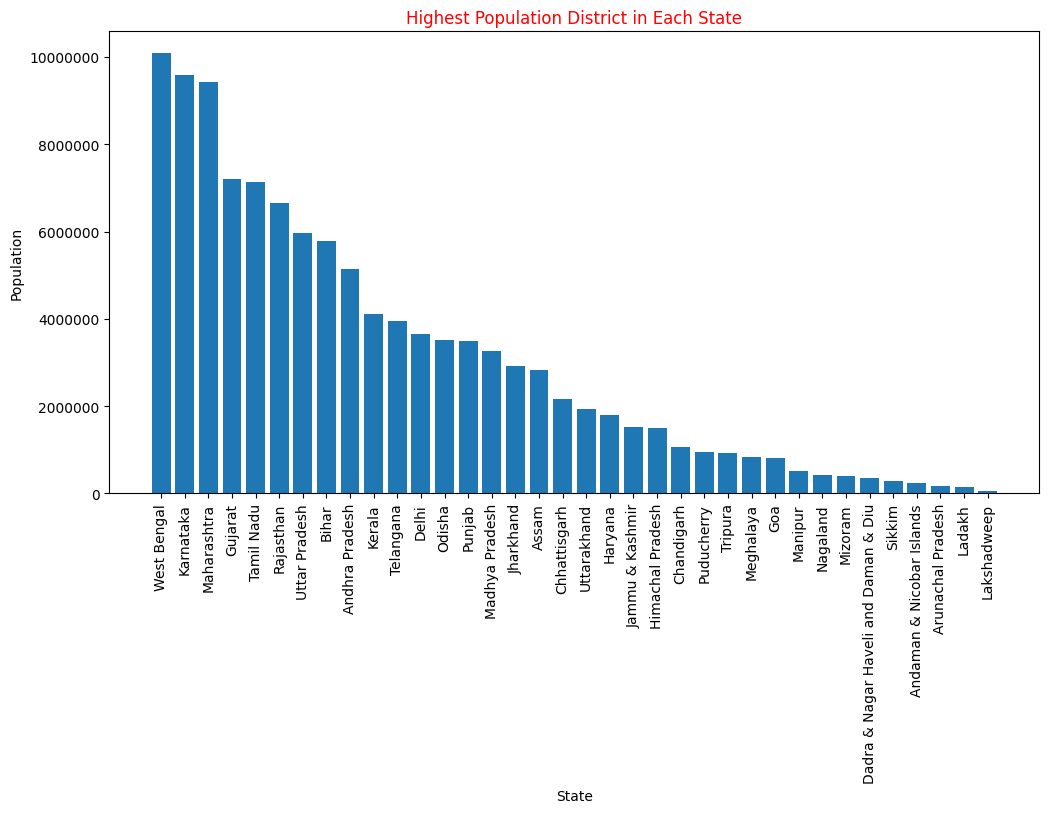

In [45]:
# 2. Create a column chart depicting the district with the highest population for each state.
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))
bar = plt.bar(pop_result['State'], pop_result['Population'])

plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Population')
plt.title('Highest Population District in Each State', color = 'red')
# plt.bar_label(bar, label_type = 'center', rotation = 90 , fmt='{:,.0f}')
plt.ticklabel_format(style='plain', axis='y')
plt.show()


In [46]:
# 2.5: Calculate the average transaction value (ATV) for each state
# 1. Compute the average transaction value for each state. Display the results in a tabular format.
df_ATV = District_Txn_Users.groupby('State')['ATV (INR)'].sum().reset_index(name = 'ATV')
head_ATV = df_ATV.sort_values('ATV', ascending = False).head()
tail_ATV = df_ATV.sort_values('ATV', ascending = False).tail()
concat_df = pd.concat([head_ATV, tail_ATV]).reset_index(drop = True)
concat_df

,State,ATV
0,Uttar Pradesh,1862192
1,Madhya Pradesh,1247001
2,Bihar,1096517
3,Tamil Nadu,1020642
4,Telangana,951982
5,Ladakh,94957
6,Dadra & Nagar Haveli and Daman & Diu,68336
7,Goa,52456
8,Lakshadweep,38865
9,Chandigarh,29592


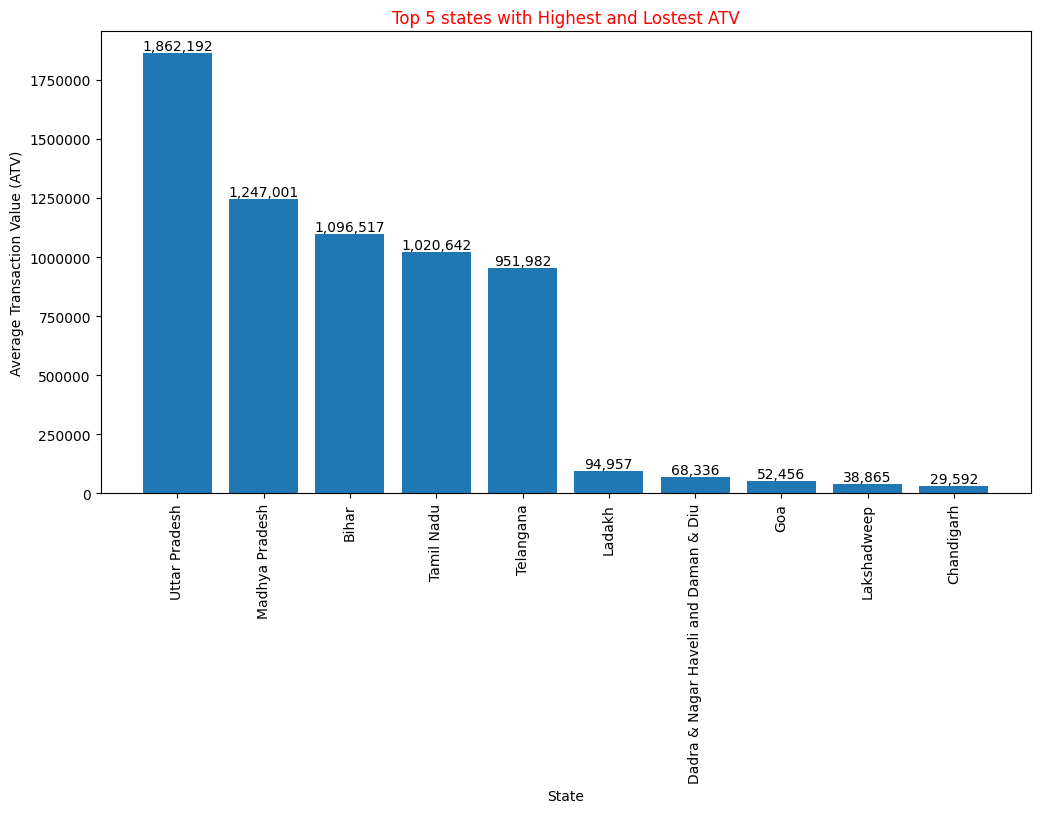

In [47]:
# 2. Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results.
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))
bar = plt.bar(concat_df['State'], concat_df['ATV'])

plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Average Transaction Value (ATV)')
plt.title('Top 5 states with Highest and Lostest ATV', color = 'red')
plt.bar_label(bar, label_type = 'edge', fmt='{:,.0f}')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [48]:
# 2.6: Analyze app usage trends
# 1. Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.
df_app_trend = (
    State_Txn_Users
    .groupby(['State','Date'])['App Opens']
    .sum()
    .reset_index()
    .sort_values(['State','Date'])
)
df_app_trend

,State,Date,App Opens
0,Andaman & Nicobar Islands,2018Q1,0
1,Andaman & Nicobar Islands,2018Q2,0
2,Andaman & Nicobar Islands,2018Q3,0
3,Andaman & Nicobar Islands,2018Q4,0
4,Andaman & Nicobar Islands,2019Q1,0
...,...,...,...
499,West Bengal,2020Q2,198589332
500,West Bengal,2020Q3,246554831
501,West Bengal,2020Q4,291721919
502,West Bengal,2021Q1,316832674


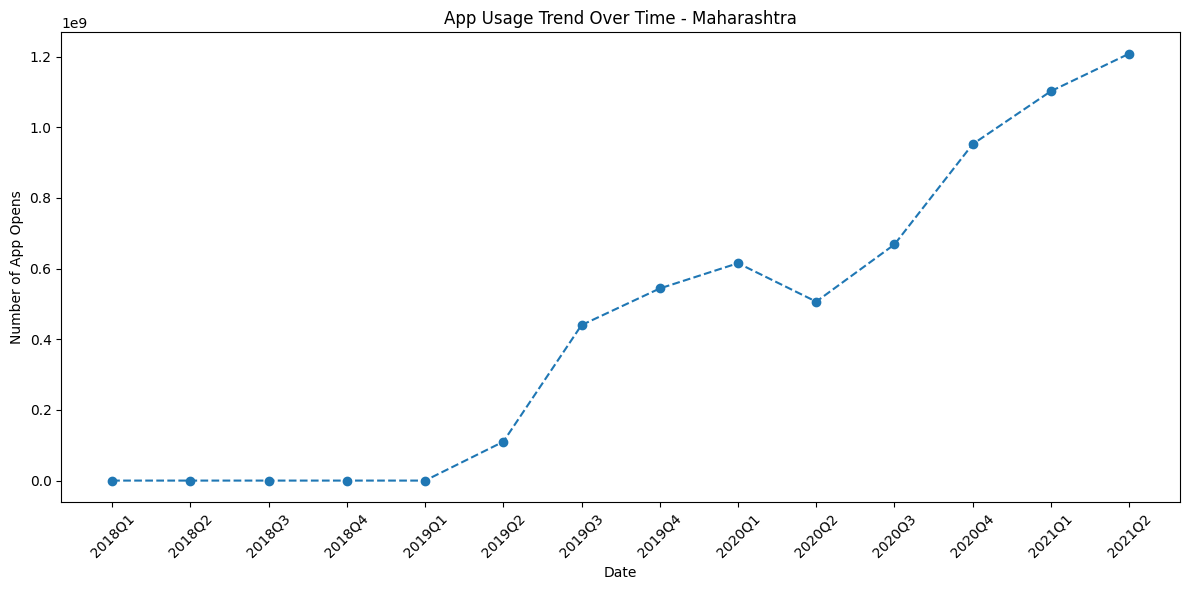

In [49]:
# 2. Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.

import matplotlib.pyplot as plt

# 🔹 Select the state you want to analyze
selected_state = "Maharashtra"   # Change as needed

# Filter and aggregate
df_state = (
    State_Txn_Users[State_Txn_Users['State'] == selected_state]
    .groupby('Date')['App Opens']
    .sum()
    .reset_index()
    .sort_values('Date')
)

# Create line plot
plt.figure(figsize = (12,6))
plt.plot(df_state['Date'], df_state['App Opens'], marker = "o", linestyle = "--")

# for i, txt in enumerate(df_state['App Opens']):
#     plt.text(df_state['Date'].iloc[i], df_state['App Opens'].iloc[i], txt)

plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of App Opens")
plt.title(f"App Usage Trend Over Time - {selected_state}")

plt.tight_layout()
plt.show()

In [ ]:
# 2.7: Distribution of transaction types
# 1. Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.
import matplotlib.pyplot as plt
import seaborn as sns

latest_date = State_TxnSplit['Date'].max()
latest_date_df = State_TxnSplit[State_TxnSplit['Date'] == latest_date]
txn_distribution = (
    latest_date_df.groupby(['State', 'Transaction Type'])
    .size()
    .reset_index(name='Count')
)

states = txn_distribution['State'].unique()

fig, axes = plt.subplots(
    nrows=(len(states) + 2) // 3,  
    ncols=3,
    figsize=(18, len(states) * 2),
    constrained_layout=True
)

axes = axes.flatten()

for i, state in enumerate(sorted(states)):
    state_df = txn_distribution[txn_distribution['State'] == state]
    axes[i].bar(state_df['Transaction Type'], state_df['Count'], color=sns.color_palette('Set2', len(state_df)))
    axes[i].set_title(state, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Transaction Type', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Distribution of Transaction Types by State\n(Most Recent Quarter: {latest_date})', 
             fontsize=16, fontweight='bold', color='darkblue', y=1.01)
plt.show()

In [ ]:
# 2.8: Find unique mapping between district name and district code
# 1. Identify the unique mapping between district names and district codes from the dataset.
District_Demographics.groupby('District')['Code'].nunique().sort_values(ascending=False)

In [ ]:
District_Demographics.groupby('Code')['District'].nunique().sort_values(ascending=False)

In [ ]:
unique_district_mapping = (
    District_Demographics[['District', 'Code']]
    .drop_duplicates()
    .reset_index(drop=True)
)
unique_district_mapping

In [ ]:
# 2. Create a CSV file containing the unique district name and district code mappings.
unique_district_mapping.to_csv(
    "unique_district_mapping.csv",
    index=False
)

print("CSV file created successfully!")

In [ ]:
# 3. Export the CSV file.
unique_district_mapping.to_csv(
    r"D:\Paras\My Document\Coding Ninja\Python\Case Study\Phone Pay\unique_district_mapping.csv",
    index=False
)


In [ ]:
df = pd.read_csv(r"D:\Paras\My Document\Coding Ninja\Python\Case Study\Phone Pay\unique_district_mapping.csv")
df

In [36]:
# Task 3: Data Quality Checks
# 3.1: Ensure data consistency across state and district levels
# 1. For each state, calculate the total number of transactions, 
#    total transaction amount, and total registered users by summing up the values from the district-level data.
district_txn_total = District_Txn_Users.groupby (['State']).agg({'Transactions' : 'sum', 'Amount (INR)' : 'sum', 'Registered Users' : 'sum'})
district_txn_total

,Transactions,Amount (INR),Registered Users
State,,,
Andaman & Nicobar Islands,1223565,3641817862,408396
Andhra Pradesh,1781091169,3860292139025,158007957
Arunachal Pradesh,8043799,22251830962,1862214
Assam,123577981,281408712659,26860751
Bihar,713643889,1639578926746,115284760
Chandigarh,25516542,53712084632,3801466
Chhattisgarh,241908549,415635319214,37448388
Dadra & Nagar Haveli and Daman & Diu,12462185,18658784569,2701112
Delhi,1011031124,1649942211113,95374654


In [37]:
# 2.Compare the results with the corresponding values at the state level to ensure they match.
State_Txn_total = State_Txn_Users.groupby (['State']).agg({'Transactions' : 'sum', 'Amount (INR)' : 'sum', 'Registered Users' : 'sum'})
State_Txn_total

,Transactions,Amount (INR),Registered Users
State,,,
Andaman & Nicobar Islands,1223565,3641817860,408396
Andhra Pradesh,1781091169,3842689014885,158007957
Arunachal Pradesh,8043799,22251830957,1862214
Assam,123577981,281408712658,26860751
Bihar,713643889,1639578926753,115284760
Chandigarh,25516542,53712084632,3801466
Chhattisgarh,241908549,415635319207,37448388
Dadra & Nagar Haveli and Daman & Diu,12462185,18658784569,2701112
Delhi,1011031124,1649942211117,95374654


In [38]:
comparison = district_txn_total.merge(
        State_Txn_total,
        on = 'State',
        suffixes = ('_district','_state')
    )

comparison['Transaction_diff'] = (
    comparison['Transactions_district']
    -comparison['Transactions_state']
).abs()

comparison['Amount_diff'] = (
    comparison['Amount (INR)_district']
    -comparison['Amount (INR)_state']
).abs()

comparison['Users_diff'] = (
    comparison['Registered Users_district']
    -comparison['Registered Users_state']
).abs()

comparison

,Transactions_district,Amount (INR)_district,Registered Users_district,Transactions_state,Amount (INR)_state,Registered Users_state,Transaction_diff,Amount_diff,Users_diff
State,,,,,,,,,
Andaman & Nicobar Islands,1223565,3641817862,408396,1223565,3641817860,408396,0,2,0
Andhra Pradesh,1781091169,3860292139025,158007957,1781091169,3842689014885,158007957,0,17603124140,0
Arunachal Pradesh,8043799,22251830962,1862214,8043799,22251830957,1862214,0,5,0
Assam,123577981,281408712659,26860751,123577981,281408712658,26860751,0,1,0
Bihar,713643889,1639578926746,115284760,713643889,1639578926753,115284760,0,7,0
Chandigarh,25516542,53712084632,3801466,25516542,53712084632,3801466,0,0,0
Chhattisgarh,241908549,415635319214,37448388,241908549,415635319207,37448388,0,7,0
Dadra & Nagar Haveli and Daman & Diu,12462185,18658784569,2701112,12462185,18658784569,2701112,0,0,0
Delhi,1011031124,1649942211113,95374654,1011031124,1649942211117,95374654,0,4,0


In [39]:
# 3. Display any discrepancies found between the district-level and state-level data.
discrepancies = comparison[
    (comparison['Transaction_diff'] != 0) |
    (comparison['Amount_diff'] != 0) |
    (comparison['Users_diff'] != 0)
]

if discrepancies.empty:
    print("✅ Data is consistent across state and district levels.")
else:
    print("⚠️ Data discrepancies found:")
    display(discrepancies)

⚠️ Data discrepancies found:


,Transactions_district,Amount (INR)_district,Registered Users_district,Transactions_state,Amount (INR)_state,Registered Users_state,Transaction_diff,Amount_diff,Users_diff
State,,,,,,,,,
Andaman & Nicobar Islands,1223565,3641817862,408396,1223565,3641817860,408396,0,2,0
Andhra Pradesh,1781091169,3860292139025,158007957,1781091169,3842689014885,158007957,0,17603124140,0
Arunachal Pradesh,8043799,22251830962,1862214,8043799,22251830957,1862214,0,5,0
Assam,123577981,281408712659,26860751,123577981,281408712658,26860751,0,1,0
Bihar,713643889,1639578926746,115284760,713643889,1639578926753,115284760,0,7,0
Chhattisgarh,241908549,415635319214,37448388,241908549,415635319207,37448388,0,7,0
Delhi,1011031124,1649942211113,95374654,1011031124,1649942211117,95374654,0,4,0
Goa,24481604,44271871113,4755320,24481604,44271871111,4755320,0,2,0
Gujarat,612992823,1105328681956,126380032,612992823,1105328681945,126380032,0,11,0


In [40]:
tolerance = 1 

discrepancies = comparison[
    (comparison['Transaction_diff'] > tolerance) |
    (comparison['Amount_diff'] > tolerance) |
    (comparison['Users_diff'] > tolerance)
]

if discrepancies.empty:
    print("✅ Data is consistent across state and district levels.")
else:
    print("⚠️ Data discrepancies found:")
    display(discrepancies)

⚠️ Data discrepancies found:


,Transactions_district,Amount (INR)_district,Registered Users_district,Transactions_state,Amount (INR)_state,Registered Users_state,Transaction_diff,Amount_diff,Users_diff
State,,,,,,,,,
Andaman & Nicobar Islands,1223565,3641817862,408396,1223565,3641817860,408396,0,2,0
Andhra Pradesh,1781091169,3860292139025,158007957,1781091169,3842689014885,158007957,0,17603124140,0
Arunachal Pradesh,8043799,22251830962,1862214,8043799,22251830957,1862214,0,5,0
Bihar,713643889,1639578926746,115284760,713643889,1639578926753,115284760,0,7,0
Chhattisgarh,241908549,415635319214,37448388,241908549,415635319207,37448388,0,7,0
Delhi,1011031124,1649942211113,95374654,1011031124,1649942211117,95374654,0,4,0
Goa,24481604,44271871113,4755320,24481604,44271871111,4755320,0,2,0
Gujarat,612992823,1105328681956,126380032,612992823,1105328681945,126380032,0,11,0
Haryana,567751410,1059831565196,85564119,567751410,1059831565200,85564119,0,4,0


In [41]:
# Task 4: Data Merging and Advanced Analysis
# 4.1: Ratio of users to population by state
# 1. Merge the State_Txn and Users dataset with the District Demographics dataset to calculate the ratio of 
    # registered users to the population for each state. Display the results in a tabular format.

district_population = (
    District_Demographics
    .groupby(['State'])['Population']
    .sum()
    .reset_index()
)

state_users = (
    State_Txn_Users
    .groupby(['State','Date'])['Registered Users']
    .sum()
    .reset_index()
)

pop_ratio_merge = (
    state_users.merge(
    district_population,
    on = "State"
    ).reset_index(drop = True)
)

pop_ratio_merge['Pop_Ratio'] = (pop_ratio_merge['Registered Users']/pop_ratio_merge['Population'] * 100).round(2)

pop_ratio_merge

,State,Date,Registered Users,Population,Pop_Ratio
0,Andaman & Nicobar Islands,2018Q1,6740,380581,1.77
1,Andaman & Nicobar Islands,2018Q2,9405,380581,2.47
2,Andaman & Nicobar Islands,2018Q3,12149,380581,3.19
3,Andaman & Nicobar Islands,2018Q4,15222,380581,4.00
4,Andaman & Nicobar Islands,2019Q1,18596,380581,4.89
...,...,...,...,...,...
499,West Bengal,2020Q2,13222022,92828987,14.24
500,West Bengal,2020Q3,14448366,92828987,15.56
501,West Bengal,2020Q4,15662093,92828987,16.87
502,West Bengal,2021Q1,16808799,92828987,18.11


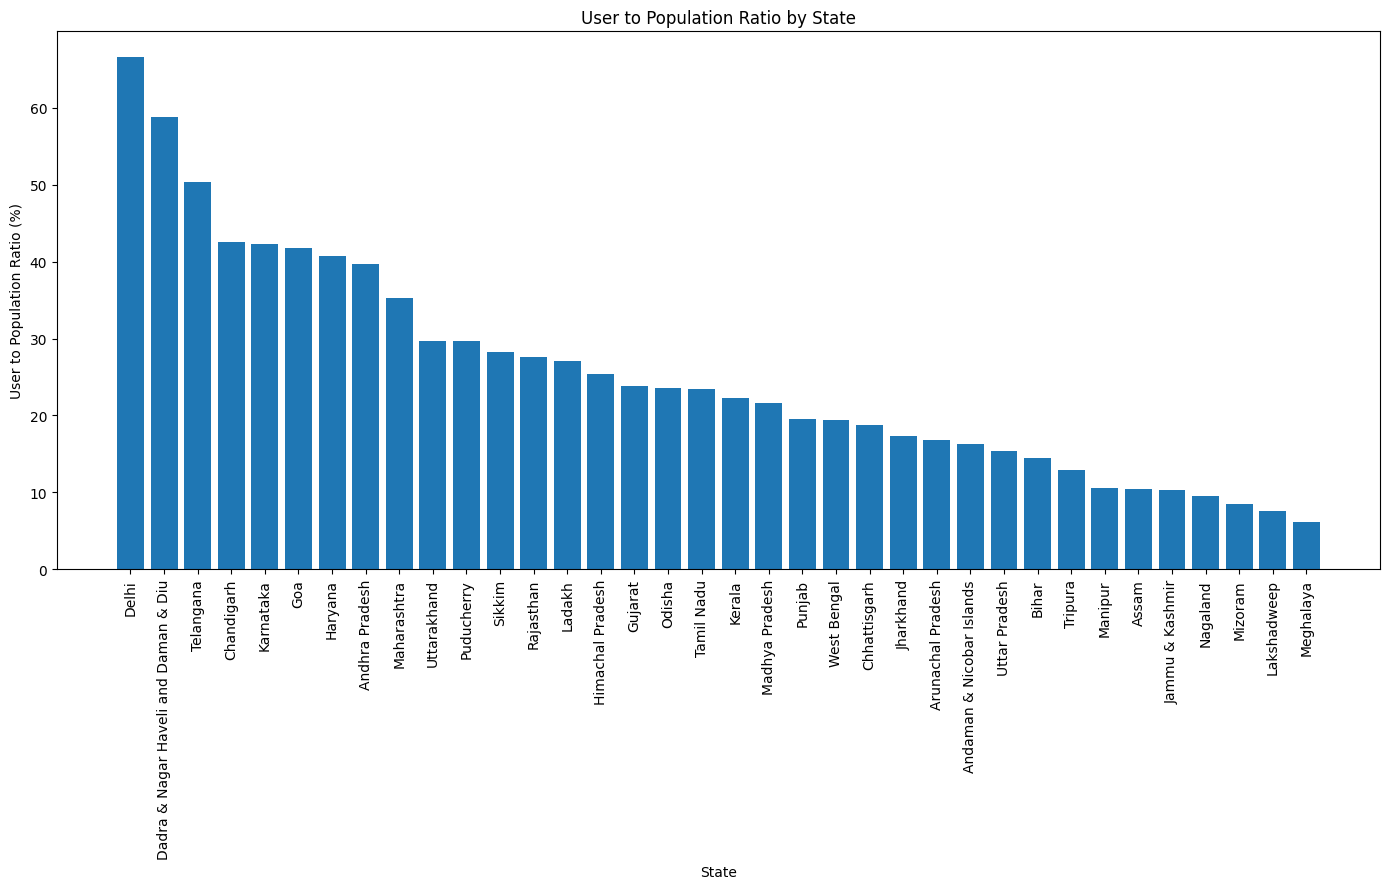

In [42]:
# 2. Create a column chart depicting the ratio of users to population by state.
import matplotlib.pyplot as plt

chart_data = pop_ratio_merge.sort_values(by='Pop_Ratio', ascending=False)

plt.figure(figsize=(14,9))

chart =plt.bar(chart_data['State'], chart_data['Pop_Ratio'])

plt.xlabel("State")
plt.ylabel("User to Population Ratio (%)")
plt.title("User to Population Ratio by State")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [43]:
# 4.2: Correlate population density with transaction volume
# 1. Merge the District_Txn and Users dataset with the District Demographics dataset.

district_population = (
    District_Demographics
    .groupby(['State','District'])['Density']
    .sum()
    .reset_index()
)

district_Users = (
    District_Txn_Users
    .groupby(['State','District'])['Transactions']
    .sum()
    .reset_index()
)

pop_tnx_merge = (
    district_Users.merge(
    district_population,
    on = ["State","District"]
    ).reset_index(drop = True)
)

# 2. Calculate the correlation between population density and transaction volume.

pop_tnx_merge[['Density','Transactions']].corr()


,Density,Transactions
Density,1.000000,0.418804
Transactions,0.418804,1.000000


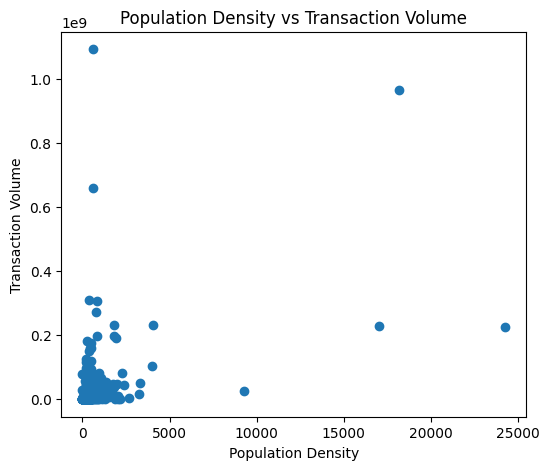

In [44]:
# 3.	Create a scatter plot to visualize the correlation between population density and transaction volume.
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(pop_tnx_merge['Density'],
            pop_tnx_merge['Transactions'])

plt.xlabel("Population Density")
plt.ylabel("Transaction Volume")
plt.title("Population Density vs Transaction Volume")
plt.show()

In [45]:
# 4.3: Average transaction amount per user
# 1. Merge relevant datasets to calculate the average transaction amount per user for each state. Display the results in a tabular format.
state_metrics = (
    State_Txn_Users
    .groupby('State')
    .agg({
        'Amount (INR)': 'sum',
        'Registered Users': 'sum'
    })
    .reset_index()
)

state_metrics['Avg_Txn_Amount_Per_User'] = (
    state_metrics['Amount (INR)'] /
    state_metrics['Registered Users']
).round(2)

state_metrics = state_metrics.sort_values(
    by='Avg_Txn_Amount_Per_User',
    ascending=False
).reset_index()

df = state_metrics[['State','Amount (INR)','Registered Users','Avg_Txn_Amount_Per_User']]
df

,State,Amount (INR),Registered Users,Avg_Txn_Amount_Per_User
0,Telangana,4574245879739,149224214,30653.51
1,Andhra Pradesh,3842689014885,158007957,24319.59
2,Karnataka,4361395878907,203098564,21474.28
3,Rajasthan,2625584351282,149770064,17530.77
4,Delhi,1649942211117,95374654,17299.59
5,Manipur,35793251135,2317734,15443.21
6,Madhya Pradesh,1915100967833,125339823,15279.27
7,Odisha,1220614556988,80404103,15181.0
8,Bihar,1639578926753,115284760,14221.99
9,Chandigarh,53712084632,3801466,14129.31


In [46]:
# 2. Identify the top 5 states with the highest average transaction amount per user and the top 5 states 
    # with the lowest average transaction amount per user. Display the results.
concat_df1 = pd.concat([df.head(5),df.tail(5)])
concat_df1

,State,Amount (INR),Registered Users,Avg_Txn_Amount_Per_User
0,Telangana,4574245879739,149224214,30653.51
1,Andhra Pradesh,3842689014885,158007957,24319.59
2,Karnataka,4361395878907,203098564,21474.28
3,Rajasthan,2625584351282,149770064,17530.77
4,Delhi,1649942211117,95374654,17299.59
31,Himachal Pradesh,97865455329,13373980,7317.6
32,Kerala,372959870820,51267042,7274.85
33,Dadra & Nagar Haveli and Daman & Diu,18658784569,2701112,6907.82
34,Tripura,20970514762,3661575,5727.18
35,Lakshadweep,192158684,34223,5614.9


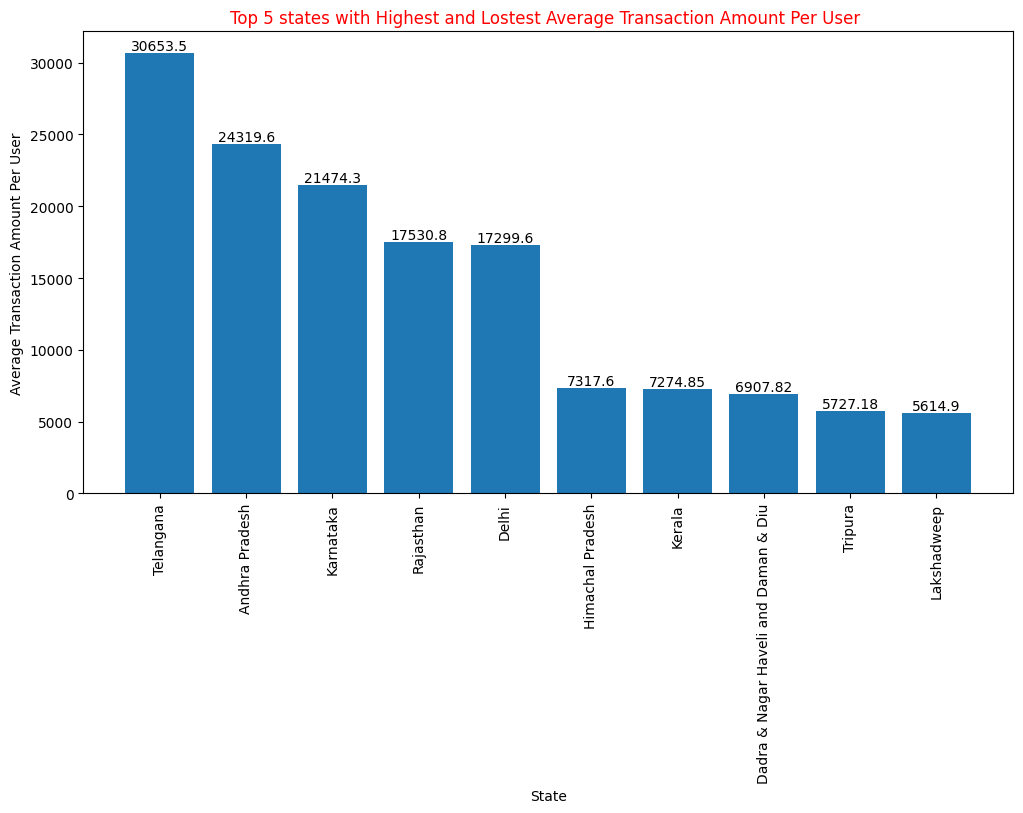

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))
bar1 = plt.bar(concat_df1['State'], concat_df1['Avg_Txn_Amount_Per_User'])

plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Average Transaction Amount Per User')
plt.title('Top 5 states with Highest and Lostest Average Transaction Amount Per User ', color = 'red')
plt.bar_label(bar1, label_type = 'edge')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [48]:
# 4.4: Device brand usage ratio
# 1. Merge the State_DeviceData dataset with the State_Txn and Users dataset.
State_Devdata = (
    state_DeviceData
    .groupby(['State','Brand','Date'])
    .agg({'Registered Users' :	'sum'})
    .reset_index()
)

State_Users = (
    State_Txn_Users
    .groupby(['State','Date'])
    .agg({'Registered Users':'sum'})
    .reset_index()
)

User_State_brand = State_Users.merge(
    State_Devdata,
    on = ['State','Date'],
    suffixes = ['_state','_brand']
)

User_State_brand['Brand_Usage_Ratio'] = (
    User_State_brand['Registered Users_brand'] /
    User_State_brand['Registered Users_state']
).round(4)

User_State_brand

,State,Date,Registered Users_state,Brand,Registered Users_brand,Brand_Usage_Ratio
0,Andaman & Nicobar Islands,2018Q1,6740,Apple,229,0.0340
1,Andaman & Nicobar Islands,2018Q1,6740,Huawei,158,0.0234
2,Andaman & Nicobar Islands,2018Q1,6740,Lenovo,202,0.0300
3,Andaman & Nicobar Islands,2018Q1,6740,Motorola,226,0.0335
4,Andaman & Nicobar Islands,2018Q1,6740,OnePlus,332,0.0493
...,...,...,...,...,...,...
5539,West Bengal,2021Q2,17979979,Others,1928653,0.1073
5540,West Bengal,2021Q2,17979979,Realme,1419072,0.0789
5541,West Bengal,2021Q2,17979979,Samsung,3778434,0.2101
5542,West Bengal,2021Q2,17979979,Vivo,2703412,0.1504


In [49]:
# 2. Calculate the ratio of users using each device brand to the total number of registered users in each state. 
    # Display the results in a tabular format.
brand_df = User_State_brand[['State','Brand','Brand_Usage_Ratio']]
brand_df

,State,Brand,Brand_Usage_Ratio
0,Andaman & Nicobar Islands,Apple,0.0340
1,Andaman & Nicobar Islands,Huawei,0.0234
2,Andaman & Nicobar Islands,Lenovo,0.0300
3,Andaman & Nicobar Islands,Motorola,0.0335
4,Andaman & Nicobar Islands,OnePlus,0.0493
...,...,...,...
5539,West Bengal,Others,0.1073
5540,West Bengal,Realme,0.0789
5541,West Bengal,Samsung,0.2101
5542,West Bengal,Vivo,0.1504


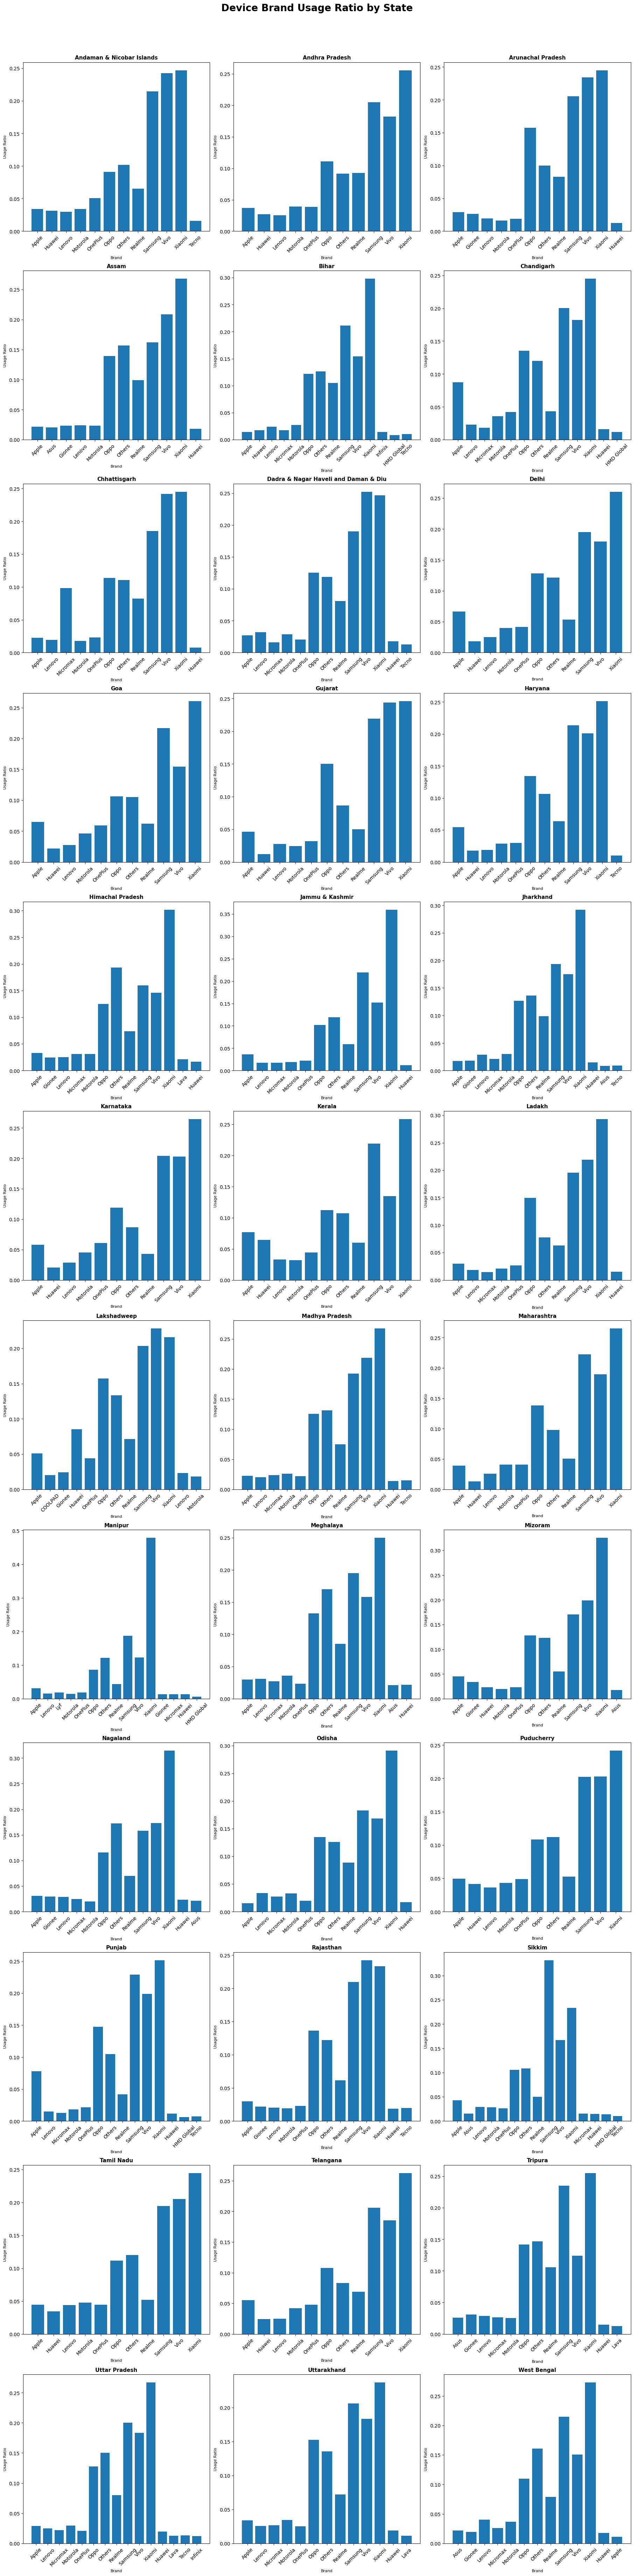

In [50]:
#3. Create a bar chart depicting the device brand usage ratio for each state.
import matplotlib.pyplot as plt
import seaborn as sns

states = brand_df['State'].unique()

fig, axes = plt.subplots(
    nrows=(len(states) + 2) // 3,
    ncols=3,
    figsize=(18, len(states) * 2),
    constrained_layout=True
)

axes = axes.flatten()

for i, state in enumerate(sorted(states)):
    
    state_df = brand_df[brand_df['State'] == state]
    
    bars = axes[i].bar(
        state_df['Brand'],
        state_df['Brand_Usage_Ratio']
    )
    
    axes[i].set_title(state, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Brand', fontsize=8)
    axes[i].set_ylabel('Usage Ratio', fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

    
# Hide unused plots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Device Brand Usage Ratio by State',
    fontsize=20,
    fontweight='bold',
    y=1.02
)

plt.show()

Write State Name:  Delhi


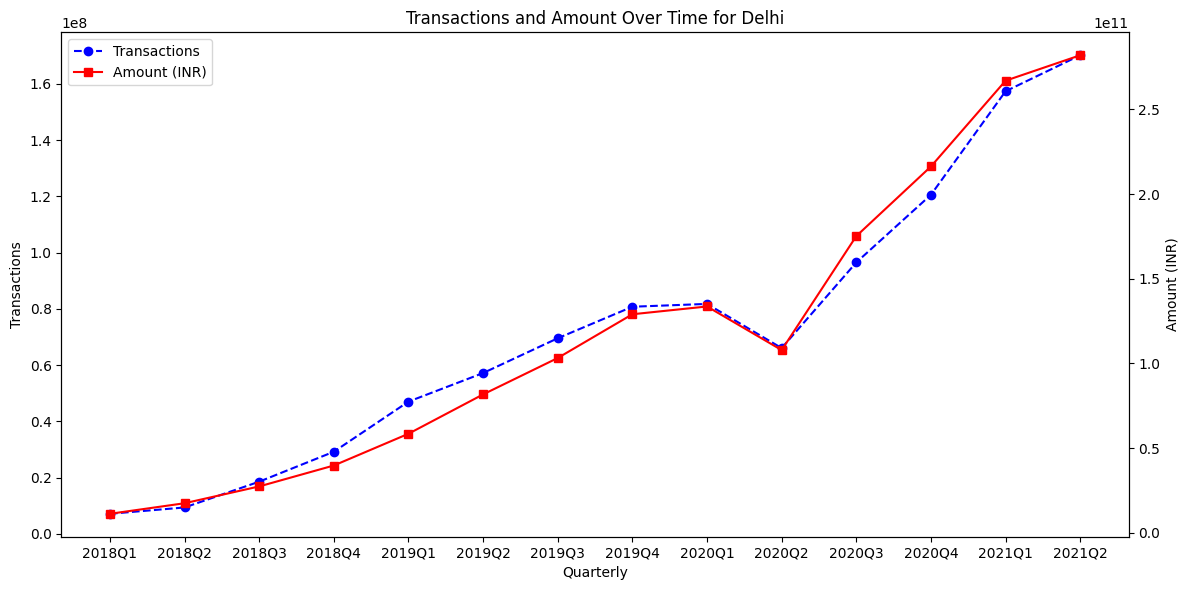

In [51]:
# Task 5: Data Visualization
# 5.1: Plot the total transactions and amount over time for a selected state
# 1. Create a line plot showing the total number of transactions and the total transaction 
#     amount over time (years and quarters) for a selected state.
#     (Hint: you can select any state, maybe your home state or state with max transactions)

import matplotlib.pyplot as plt

State_name = input("Write State Name: ")

dnm_state_tnx = State_Txn_Users[
    State_Txn_Users['State'] == State_name
].sort_values('Date')

fig, ax1 = plt.subplots(figsize=(12,6))

# Line 1 → Transactions
line1, = ax1.plot(
    dnm_state_tnx['Date'],
    dnm_state_tnx['Transactions'],
    marker='o',
    linestyle='--',
    label='Transactions',
    color = 'blue'
)

ax1.set_xlabel('Quarterly')
ax1.set_ylabel('Transactions')

# Line 2 → Amount
ax2 = ax1.twinx()

line2, = ax2.plot(
    dnm_state_tnx['Date'],
    dnm_state_tnx['Amount (INR)'],
    marker='s',
    linestyle='-',
    label='Amount (INR)',
    color = 'red'
)

ax2.set_ylabel('Amount (INR)')

lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title(f'Transactions and Amount Over Time for {State_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Enter State Name:  Delhi
Enter Year (e.g., 2018):  2018
Enter Quarter (1-4):  3


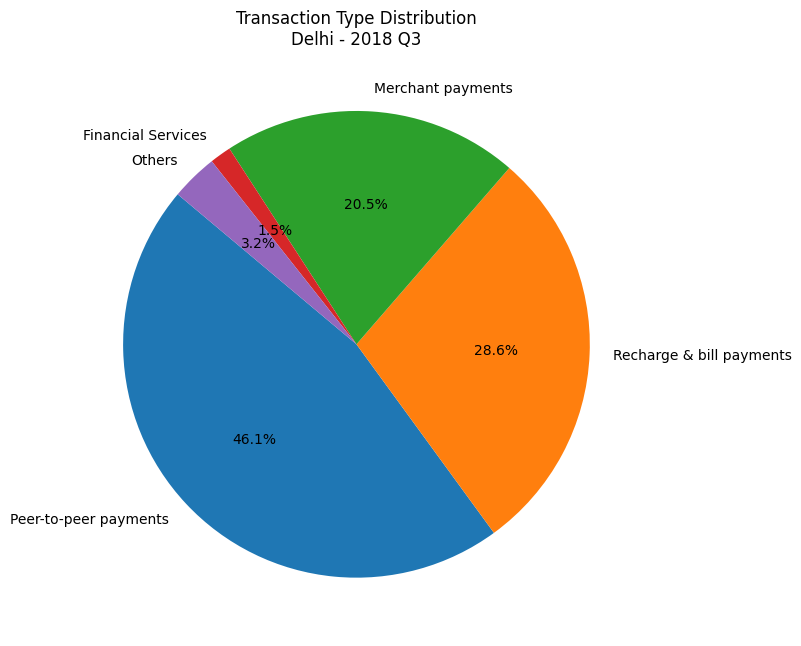

In [53]:
# 5.2: Create a pie chart showing the distribution of transaction types for a specific quarter
# 1. Create a pie chart showing the distribution of different transaction types for a selected state and quarter.
import matplotlib.pyplot as plt

state_name = input("Enter State Name: ")
year = int(input("Enter Year (e.g., 2018): "))
quarter = int(input("Enter Quarter (1-4): "))

filtered_data = State_TxnSplit[
    (State_TxnSplit['State'] == state_name) &
    (State_TxnSplit['Year'] == year) &
    (State_TxnSplit['Quarter'] == quarter)
]

if filtered_data.empty:
    print("No data found for this selection.")
else:
    plt.figure(figsize=(8,8))

    plt.pie(
        filtered_data['Transactions'],
        labels= filtered_data['Transaction Type'],
        autopct='%1.1f%%',
        startangle=140
    )

    plt.title(f"Transaction Type Distribution\n{state_name} - {year} Q{quarter}")
    plt.tight_layout()
    plt.show()

Enter State Name:  Delhi


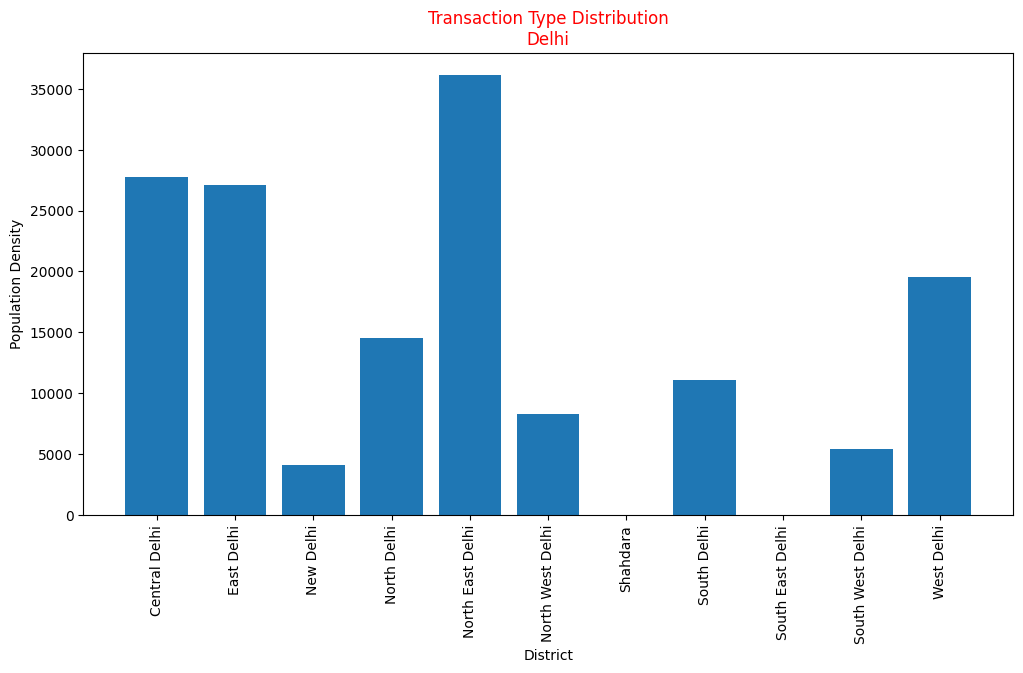

In [54]:
# 5.3: Visualize the population density of districts in a selected state
# 1. Create a bar plot showing the population density of districts in a selected state.
state_name = input("Enter State Name: ")

pop_density_district = District_Demographics[(District_Demographics['State'] == state_name)]

if pop_density_district.empty:
    print("No data found for this selection.")
else:
    plt.figure(figsize=(12,6))
    bars = plt.bar(
        pop_density_district['District'],
        pop_density_district['Density'],
    )

    plt.title(f"Transaction Type Distribution\n{state_name}", color = 'red')
    plt.xlabel("District")
    plt.ylabel("Population Density")
    # plt.bar_label(bars)
    plt.xticks(rotation = 90)
    plt.show()

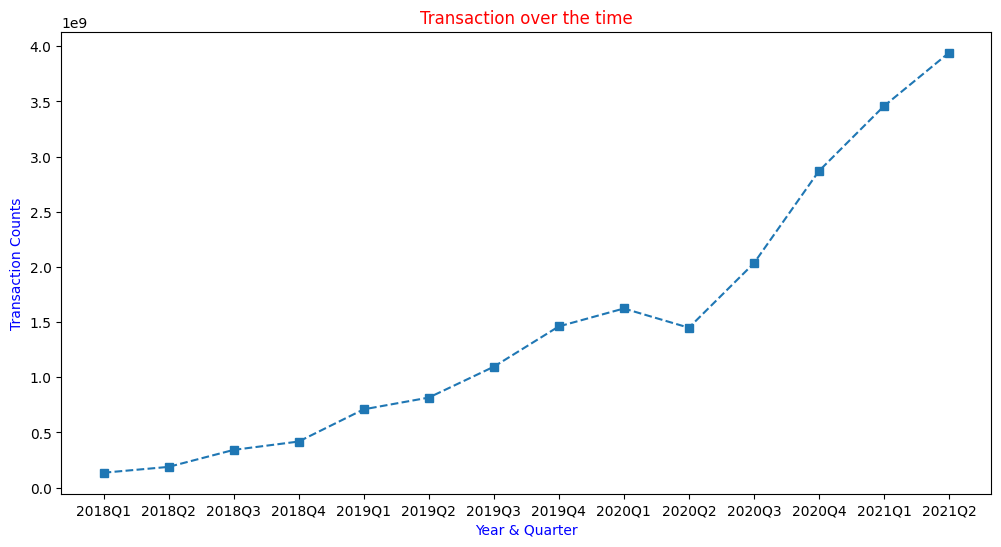

In [64]:
# Task 6: Insights and Conclusions (Advanced Section)
# 6.1: Identify any trends or patterns in the transaction data
# 1. Analyze the transaction data to identify any noticeable trends or patterns.

tnx_trend = State_Txn_Users.groupby(['Date'])['Transactions'].sum().reset_index()

import matplotlib.pyplot as pd
plt.figure(figsize = (12,6))
plt.plot(tnx_trend['Date'],tnx_trend['Transactions'], marker = 's', linestyle = '--')

plt.title("Transaction over the time", color = 'red')
plt.xlabel('Year & Quarter', color = 'blue')
plt.ylabel('Transaction Counts', color = 'blue')
plt.show()

# Transaction Trend Analysis (2018Q1 – 2021Q2)
🔹 1. Strong Overall Upward Trend

- Transactions increased consistently from 2018 to 2021.

- Growth is especially sharp after 2020Q2.

- Indicates strong digital adoption over time.

This shows long-term expansion in transaction volume.

🔹 2. Gradual Growth Phase (2018–2019)

From:
- ~0.15 billion in 2018Q1
To:
- ~1.47 billion in 2019Q4

This suggests:
- Increasing user base
- Growing trust in digital payments
- Platform maturity

Growth is steady and organic.

🔹 3. Temporary Dip in 2020Q2

There is a visible drop in 2020Q2.

Likely explanation:
- COVID-19 lockdown disruptions
- Reduced commercial activity
- Supply chain interruptions

This reflects real-world macroeconomic impact.

🔹 4. Explosive Growth Post-2020Q2

From:
- ~1.45 billion (2020Q2)
To:
- ~3.95 billion (2021Q2)

This is the sharpest growth phase.

Possible reasons:
- Increased digital payment adoption during pandemic
- Shift to contactless transactions
- Government push for digital economy

This phase shows structural change in consumer behavior.- 

### Key Insight (High-Impact Statement for Interview)

The data shows a strong long-term upward trend with a temporary pandemic-related dip in 2020Q2, followed by accelerated growth. This suggests a structural shift toward digital transactions rather than short-term fluctuation.

That sentence alone sounds very professional.

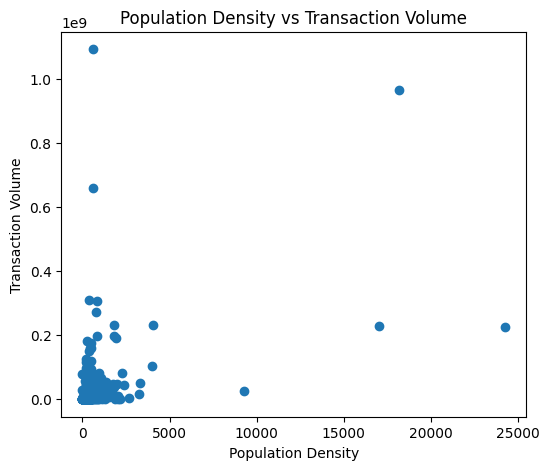

In [66]:
# 6.2: Correlate demographic data with transaction data
# 1. Find correlations between demographic data (e.g., population density) and transaction data (e.g., transaction volume). Summarize your findings.# (Hint: you can use corr())
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(pop_tnx_merge['Density'],
            pop_tnx_merge['Transactions'])

plt.xlabel("Population Density")
plt.ylabel("Transaction Volume")
plt.title("Population Density vs Transaction Volume")
plt.show()

# Chart Insights — Population Density vs Transaction Volume

- No clear linear relationship is visible between population density and transaction volume from this scatter plot — the data points are widely scattered without forming any obvious upward or downward trend, suggesting the correlation between these two variables is weak.
- The majority of data points cluster heavily in the low population density range (0–2,000) with highly varying transaction volumes — meaning states with similar population densities can have dramatically different transaction volumes, indicating other factors are at play.
- Two significant outliers stand out at low population density but extremely high transaction volume (top-left area, around 110 Crores and 65 Crores) — these likely represent large states with low density but massive economies, such as Texas or California, where geographic spread doesn't limit economic activity.
- One notable outlier exists at high population density (~18,000) with a transaction volume of approximately 97 Crores — this likely represents a small, densely packed state or urban region with an intensely active financial ecosystem.
- The rightmost point (~24,000 population density) shows only moderate transaction volume of approximately 22 Crores — suggesting that extreme density alone does not guarantee proportionally high transaction activity.
- The overall pattern suggests population density is not a reliable standalone predictor of transaction volume, and a formal correlation analysis is needed to quantify the relationship precisely.